# NLP Today Session 03: Word Embeddings

### Students:
- Zakaria SOUALAH MOHAMMED (zakaria.soualah-mohammed@universite-paris-saclay.fr)
- Wissam AMAR (wissam.amar@universite-paris-saclay.fr)

## Objectives

The objective of this lab is to build, evaluate, and compare different word embedding models using **Gensim** and **FastText**.
These embeddings are trained on two corpora:
1. Medical corpus (small and specialty-domain): `QUAERO_FrenchMed`
2. Press corpus (large and open-domain): `QUAERO_FrenchPress`

We train **6 embedding models** in total across 3 approaches:
- Word2Vec Continuous Bag-of-Words (CBOW)
- Word2Vec Skip-gram (SG)
- FastText Continuous Bag-of-Words (CBOW)

With the following hyperparameters:
- Vector dimension: `dim = 100`
- Minimum word frequency: `min_count = 1`

Finally, we evaluate:
- **Semantic similarity** using both `scipy.spatial` cosine distance and Gensim's `most_similar` method on candidate words (`patient`, `traitement` / treatment, `maladie` / disease, `solution`, `jaune` / yellow).
- **Comparative analysis**: impact of model architecture vs. impact of corpus type/size (domain shift and polysemy).
- **t-SNE 2D projections** to visualize geometric structure in vector space.


## 1. Setup and Environment

In [24]:
# !pip install gensim fasttext-wheel scikit-learn matplotlib pandas scipy

import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist, cosine
from sklearn.manifold import TSNE
from gensim.models import Word2Vec, FastText

# Ensuring plots render nicely inline
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
print("Environment configured successfully!")


Environment configured successfully!


## 2. Corpus Loading and Exploration

The data consists of two corpora in `.ospl` format (*one sentence per line*, pre-tokenized with whitespace):

| Corpus | Description |
|:--|:--|
| `QUAERO_FrenchMed_traindev.ospl` | EMEA and MEDLINE French medical documents |
| `QUAERO_FrenchPress_traindev.ospl` | French journalistic press articles |


In [13]:
# Define data paths
data_dir = "data"
med_path = os.path.join(data_dir, "QUAERO_FrenchMed", "QUAERO_FrenchMed_traindev.ospl")
press_path = os.path.join(data_dir, "QUAERO_FrenchPress", "QUAERO_FrenchPress_traindev.ospl")

def load_ospl_corpus(filepath):
    """Loads a space-tokenized sentence-per-line file."""
    sentences = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            tokens = line.strip().split()
            if tokens:
                sentences.append(tokens)
    return sentences

t0 = time.time()
med_sentences = load_ospl_corpus(med_path)
press_sentences = load_ospl_corpus(press_path)

med_tokens = sum(len(s) for s in med_sentences)
press_tokens = sum(len(s) for s in press_sentences)

med_vocab = set(w for s in med_sentences for w in s)
press_vocab = set(w for s in press_sentences for w in s)

print("=" * 65)
print(f"CORPUS STATISTICS:")
print("=" * 65)
print(f"Medical Corpus: {len(med_sentences):,} sentences | {med_tokens:,} tokens | {len(med_vocab):,} unique words")
print(f"Press Corpus:   {len(press_sentences):,} sentences | {press_tokens:,} tokens | {len(press_vocab):,} unique words")
print(f"Vocabulary Overlap: {len(med_vocab & press_vocab):,} common words")
print(f"Medical-specific words: {len(med_vocab - press_vocab):,}")
print(f"Loading time: {time.time() - t0:.2f}s")


CORPUS STATISTICS:
Medical Corpus: 3,021 sentences | 51,896 tokens | 9,104 unique words
Press Corpus:   38,548 sentences | 1,251,561 tokens | 39,654 unique words
Vocabulary Overlap: 3,753 common words
Medical-specific words: 5,351
Loading time: 0.49s


In [14]:
# Display sample sentences from each corpus
print("--- Medical Corpus Sample Sentences ---")
for i, s in enumerate(med_sentences[3:6], 1):
    print(f"[{i}] {' '.join(s[:25])}...")

print("\n--- Press Corpus Sample Sentences ---")
for i, s in enumerate(press_sentences[4:7], 1):
    print(f"[{i}] {' '.join(s[:25])}...")


--- Medical Corpus Sample Sentences ---
[1] Prialt est une solution pour perfusion contenant le principe actif ziconotide , à des concentrations de 100 ou 25 microgrammes par millilitre ....
[2] Dans quel cas Prialt est - il utilisé ?...
[3] Prialt est indiqué pour le traitement des douleurs intenses , chroniques ( de long terme ) chez les patients nécessitant une analgésie intrarachidienne ( injection...

--- Press Corpus Sample Sentences ---
[1] deux incendies cette nuit en région parisienne , dans une maison de retraite de Livry-Gargan en Seine-Saint-Denis , 7 personnes ont péri dans les flammes...
[2] et puis dans le neuvième arrondissement de Paris , le feu a pris dans un immeuble d' habitation et 3 personnes ont été tuées ....
[3] le sculpteur César est décédé hier à l' âge de 77 ans , il était devenu célèbre grâce à ses compressions et à ses oeuvres...


## 3. Training the Embedding Models

### Explanation of Model Architectures:
1. **Word2Vec CBOW**: Continuous Bag of Words predicts the target word from its context words. It optimizes:
   $$\mathcal{L}_{CBOW} = \sum_{t} \log P(w_t \mid w_{t-c}, \dots, w_{t+c})$$
   It operates very fast and tends to capture syntactic categories well by averaging context vectors.

   <div style="text-align: center;">
      <img src="notebook_images/cbow.png" style="width: 50%;">
   </div>

<br>

2. **Word2Vec Skip-Gram**: Predicts the surrounding context words given the target word:
   $$\mathcal{L}_{SG} = \sum_{t} \sum_{-c \le j \le c, j \ne 0} \log P(w_{t+j} \mid w_t)$$
   Skip-gram treats each context word pair independently, producing sharper representations for rare words and semantic synonyms.

   <div style="text-align: center;">
      <img src="notebook_images/sg.png" style="width: 50%;">
   </div>

<br>

3. **FastText CBOW**: Enriches word representations by breaking each word into character $n$-grams (for example, $3 \le n \le 6$):
   $$\mathbf{v}_w = \sum_{g \in \mathcal{G}_w} \mathbf{z}_g$$
   This subword representation allows FastText to capture prefixes, suffixes (e.g., `-ite`, `-ose`, `-ement`), compound words, and even infer embeddings for out-of-vocabulary (OOV) tokens.

   <div style="text-align: center;">
      <img src="notebook_images/fasttext.png" style="width: 50%;">
   </div>

<br>

### Hyperparameters:
- `vector_size = 100` (dim = 100)
- `min_count = 1` (retain all words)
- `window = 5`
- `epochs = 5`


In [15]:
# Output directory for models and exported vectors
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

models = {}

def train_and_save(corpus_name, sentences, model_type, sg, is_fasttext=False, dim=100, min_count=1, epochs=5):
    name = f"{'fasttext' if is_fasttext else 'w2v'}_{'sg' if sg==1 else 'cbow'}_{corpus_name}"
    print(f"Training {name.upper()}...")
    t_start = time.time()
    
    if is_fasttext:
        model = FastText(sentences=sentences, vector_size=dim, window=5, min_count=min_count, sg=sg, epochs=epochs, workers=4, seed=42)
    else:
        model = Word2Vec(sentences=sentences, vector_size=dim, window=5, min_count=min_count, sg=sg, epochs=epochs, workers=4, seed=42)
        
    duration = time.time() - t_start
    print(f"-> Done in {duration:.2f}s | Vocab: {len(model.wv):,} words \n")
    
    # Save full model (.model)
    model_path = os.path.join(models_dir, f"{name}.model")
    model.save(model_path)
    
    # Export vectors in standard word2vec text format (.vec) for scipy spatial loading
    vec_path = os.path.join(models_dir, f"{name}.vec")
    model.wv.save_word2vec_format(vec_path, binary=False)
    
    return model

# 1. Medical Models
print("=== Training Medical Models ===")
models["w2v_cbow_med"] = train_and_save("med", med_sentences, "w2v", sg=0)
models["w2v_sg_med"] = train_and_save("med", med_sentences, "w2v", sg=1)
models["fasttext_cbow_med"] = train_and_save("med", med_sentences, "fasttext", sg=0, is_fasttext=True)

# 2. Press Models
print("\n=== Training Press Models ===")
models["w2v_cbow_press"] = train_and_save("press", press_sentences, "w2v", sg=0)
models["w2v_sg_press"] = train_and_save("press", press_sentences, "w2v", sg=1)
models["fasttext_cbow_press"] = train_and_save("press", press_sentences, "fasttext", sg=0, is_fasttext=True)

print("All 6 models trained and saved to 'models/' successfully!")


=== Training Medical Models ===
Training W2V_CBOW_MED...
-> Done in 0.41s | Vocab: 9,104 words 

Training W2V_SG_MED...
-> Done in 0.76s | Vocab: 9,104 words 

Training FASTTEXT_CBOW_MED...
-> Done in 3.59s | Vocab: 9,104 words 


=== Training Press Models ===
Training W2V_CBOW_PRESS...
-> Done in 4.85s | Vocab: 39,654 words 

Training W2V_SG_PRESS...
-> Done in 12.63s | Vocab: 39,654 words 

Training FASTTEXT_CBOW_PRESS...
-> Done in 21.53s | Vocab: 39,654 words 

All 6 models trained and saved to 'models/' successfully!


## 4. Semantic Similarity Evaluation

We evaluate the closest words to candidate query words based on **cosine similarity**:
$$\text{Sim}_{\cos}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2} = 1 - D_{\text{cosine}}(\mathbf{u}, \mathbf{v})$$

As specified in the lab instructions, we implement **two distinct evaluation methods**:
1. **Method 1: `scipy.spatial.distance`**:
   We load the raw embedding vectors from the saved `.vec` files, compute pairwise cosine distance with `scipy.spatial.distance.cdist` (or `cosine`), and extract the top-10 words with the smallest distance ($1 - \text{dist}$).
2. **Method 2: Gensim's `most_similar`**:
   We use the native `model.wv.most_similar(word, topn=10)` method.

### Candidate Words:
The candidate word list given in the instructions is:
- `patient` (patient)
- `treatment` -> `traitement`
- `disease` -> `maladie`
- `solution` (solution)
- `yellow` -> `jaune`

*(Note: In the French corpora, we query the exact French vocabulary terms and compare their behavior).*


In [16]:
def load_vec_file(vec_filepath):
    """Loads vocabulary and numpy matrix from a .vec file."""
    words = []
    vectors = []
    with open(vec_filepath, 'r', encoding='utf-8', errors='ignore') as f:
        header = f.readline().strip().split()
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            words.append(parts[0])
            vectors.append([float(x) for x in parts[1:]])
    vectors = np.array(vectors, dtype=np.float32)
    word2idx = {w: i for i, w in enumerate(words)}
    return words, word2idx, vectors

def top_k_scipy(target_word, words, word2idx, vectors, top_k=10):
    """Finds top-k nearest words using scipy cosine distance."""
    if target_word not in word2idx:
        return []
    idx = word2idx[target_word]
    v = vectors[idx].reshape(1, -1)
    
    # Cosine distance: 0 = identical, 1 = orthogonal, 2 = opposite
    dists = cdist(v, vectors, metric='cosine')[0]
    ranked_indices = np.argsort(dists)
    
    results = []
    for i in ranked_indices:
        w = words[i]
        if w.lower() == target_word.lower():
            continue
        sim = 1.0 - dists[i]
        results.append((w, float(sim)))
        if len(results) == top_k:
            break
    return results

def top_k_gensim(target_word, model, top_k=10):
    """Finds top-k nearest words using Gensim's most_similar."""
    if target_word not in model.wv:
        return []
    return model.wv.most_similar(target_word, topn=top_k)


### 4.1. Verification: Scipy Spatial vs. Gensim `most_similar`
We verify that both methods produce strictly identical rankings and similarity scores.


In [28]:
# Check equivalence on W2V CBOW Medical for 'patient'
test_vec_path = os.path.join(models_dir, "w2v_cbow_med.vec")
words_m, w2i_m, vecs_m = load_vec_file(test_vec_path)

scipy_res = top_k_scipy("patient", words_m, w2i_m, vecs_m, top_k=5)
gensim_res = top_k_gensim("patient", models["w2v_cbow_med"], top_k=5)

print(f"{'Rank':<5} | {'Scipy Spatial Cosine':<30} | {'Gensim most_similar':<30} | {'Match?':<6}")
print("-" * 82)

for i in range(5):
    sw, ss = scipy_res[i]
    gw, gs = gensim_res[i]
    match = (sw == gw) and (abs(ss - gs) < 1e-4)

    scipy_col = f"{sw} ({ss:.4f})"
    gensim_col = f"{gw} ({gs:.4f})"

    print(f"{i+1:<5} | {scipy_col:<30} | {gensim_col:<30} | {str(match):<6}")



Rank  | Scipy Spatial Cosine           | Gensim most_similar            | Match?
----------------------------------------------------------------------------------
1     | sont (0.9993)                  | sont (0.9993)                  | True  
2     | les (0.9992)                   | les (0.9992)                   | True  
3     | le (0.9992)                    | le (0.9992)                    | True  
4     | et (0.9992)                    | et (0.9992)                    | True  
5     | que (0.9992)                   | que (0.9992)                   | True  


### 4.2. Semantic Similarity Comparison Across All 6 Models


In [31]:
candidate_words = ["patient", "traitement", "maladie", "solution", "jaune"]
model_keys = [
    ("w2v_cbow_med", "W2V CBOW (Med)"),
    ("w2v_sg_med", "W2V SG (Med)"),
    ("fasttext_cbow_med", "FastText CBOW (Med)"),
    ("w2v_cbow_press", "W2V CBOW (Press)"),
    ("w2v_sg_press", "W2V SG (Press)"),
    ("fasttext_cbow_press", "FastText CBOW (Press)")
]

for cand in candidate_words:
    print("\n" + "=" * 110)
    print(f"CANDIDATE WORD: '{cand.upper()}' (Top 10 Nearest Neighbors)")
    print("=" * 110)
    
    # Collect results
    res_dict = {
        key: top_k_gensim(cand, models[key], top_k=10)
        for key, _ in model_keys
    }

    col_width = 24

    header = f"{'Rank':<4} | " + " | ".join(
        f"{label:<{col_width}}" for _, label in model_keys
    )
    print(header)
    print("-" * len(header))

    for r in range(10):
        row = [f"{r+1:<4}"]

        for key, _ in model_keys:
            res = res_dict[key]

            if r < len(res):
                w, s = res[r]
                item = f"{w} ({s:.2f})"
            else:
                item = "N/A"

            row.append(f"{item:<{col_width}}")

        print(" | ".join(row))



CANDIDATE WORD: 'PATIENT' (Top 10 Nearest Neighbors)
Rank | W2V CBOW (Med)           | W2V SG (Med)             | FastText CBOW (Med)      | W2V CBOW (Press)         | W2V SG (Press)           | FastText CBOW (Press)   
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
1    | sont (1.00)              | recommandé (1.00)        | Patient (1.00)           | fidèle (0.90)            | mollah (0.96)            | patientent (0.99)       
2    | les (1.00)               | Tysabri (1.00)           | patiente (1.00)          | tabac (0.88)             | circonstance (0.95)      | impatient (0.99)        
3    | le (1.00)                | ce (1.00)                | présentaient (1.00)      | passeport (0.88)         | handicapé (0.95)         | trient (0.99)           
4    | et (1.00)                | nécessaire (1.00)        | agent (1.00)             | gendarme (0.88)        

## 5. Comparative Evaluation and Discussion

### 5.1. Impact of Embedding Architecture

#### 5.1.1. Word2Vec CBOW vs. Skip-gram:

The results show that **Skip-gram** generally produces more meaningful semantic neighbors than **CBOW** on the medical corpus.

For `patient`, CBOW mainly retrieves frequent words such as `sont`, `les`, `le`, `et`, and `que`. Skip-gram gives more context-related words such as `recommandé`, `Tysabri`, `nécessaire`, `administré`, `réactions`, and `grossesse`.

The same pattern appears for `traitement`. With CBOW, many of the closest words are frequent grammatical terms, while Skip-gram retrieves medical words such as `TYSABRI`, `médicaments`, `association`, `risque`, `utilisation`, and `maladie`.

For `maladie`, Skip-gram also gives more relevant neighbors such as `infection`, `adulte`, `enfant`, `étude`, and `risque`.

These results suggest that Skip-gram captures the semantic context of medical terms better than CBOW in this experiment, especially because the medical corpus is relatively small.

#### 5.1.2. Word2Vec vs. FastText:

**FastText** behaves differently from **Word2Vec** because it also uses subword information.

For `traitement`, FastText retrieves words such as `Traitement`, `traitements`, `Allaitement`, `allaitement`, `évitement`, and `traitment`. These words are strongly related by their form and shared character sequences.

For `solution`, FastText retrieves words such as `Dissolution`, `dilution`, and `Pollution`. For `maladie`, it retrieves forms such as `maladies`, `Maladie`, and `malade`.

This shows that FastText is particularly good at capturing morphological similarity. However, words that are similar in form are not always similar in meaning. In comparison, Word2Vec Skip-gram tends to produce more semantic associations, while FastText gives stronger morphological clustering.

### 5.2. Impact of Data (Domain Shift and Size)

#### 5.2.1. The Polysemy of `'solution'`:

The word `solution` shows a clear difference between the medical and press corpora.

In the Medical corpus, Skip-gram associates `solution` with words such as `flacon`, `perfusion`, `mg`, and `injectable`. These neighbors correspond to the medical use of a solution as a pharmaceutical preparation, or some chemical formula.

In the Press corpus, the meaning is more general. Skip-gram retrieves words such as `pacifique`, `règle`, `consensuelle`, `alternative`, `garantie`, and `difficulté`.

This example shows that the same word can have very different representations depending on the training corpus. The embedding therefore reflects the context and domain in which the word appears.

#### 5.2.2. The Cultural Shift of `'jaune'`:

The word `jaune` also behaves differently across the two corpora.

In the Medical corpus, its neighbors do not form a clear semantic group, suggesting that the word is not represented strongly in this dataset.

In the Press corpus, Skip-gram associates `jaune` with words such as `maillot`, `chelem`, and `Petacchi`. The association with `maillot` reflects the expression *maillot jaune*, which is common in French sports journalism.

This shows how the corpus can influence the meaning captured by the embedding, especially when a word frequently appears in a specific cultural or thematic context.

#### 5.2.3. Impact of Corpus Size:

The size of the corpus also affects the quality of the embeddings.

The `FrenchMed` corpus contains about 51,896 tokens, while the `FrenchPress` corpus contains about 1,251,561 tokens. The press corpus is therefore around 24 times larger.

On the smaller medical corpus, CBOW often produces frequent grammatical words as nearest neighbors. Skip-gram gives more meaningful domain-related results, while FastText benefits from morphological information.

On the larger press corpus, the models have more examples and contexts available during training. As a result, the semantic relationships are generally more stable and easier to interpret.

Overall, the experiments show that both the embedding architecture and the training corpus strongly influence the learned word representations.

## 6. t-SNE 2D Dimensionality Reduction and Visualization

We project the 100-dimensional embeddings down to 2 dimensions using **t-SNE** to visually analyze cluster separation.


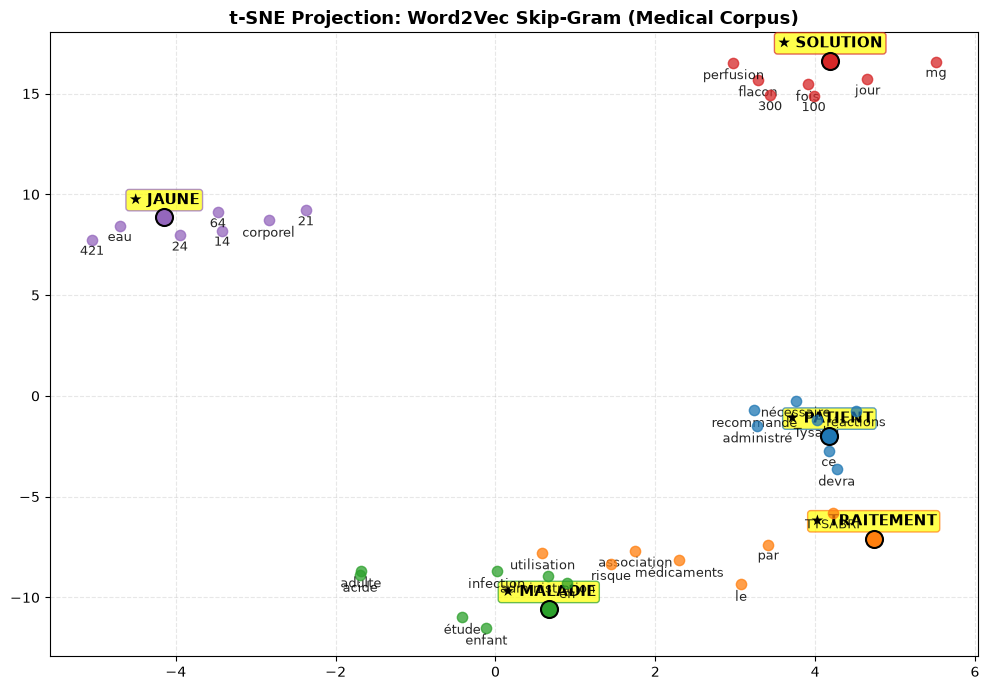

In [19]:
def plot_tsne_comparison(model, candidate_words, title, top_n=7, perplexity=8):
    """Generates a 2D t-SNE plot for candidate words and their nearest neighbors."""
    words = []
    vectors = []
    word_labels = {}
    
    for cand in candidate_words:
        if cand not in model.wv:
            continue
        words.append(cand)
        vectors.append(model.wv[cand])
        word_labels[cand] = cand
        
        neighbors = model.wv.most_similar(cand, topn=top_n)
        for nw, _ in neighbors:
            if nw not in words:
                words.append(nw)
                vectors.append(model.wv[nw])
                word_labels[nw] = cand
                
    vectors = np.array(vectors)
    eff_perp = min(perplexity, max(2, len(words) // 3))
    tsne = TSNE(n_components=2, perplexity=eff_perp, random_state=42, max_iter=1000)
    coords = tsne.fit_transform(vectors)
    
    cmap = plt.get_cmap("tab10")
    colors = {cand: cmap(i % 10) for i, cand in enumerate(candidate_words)}
    
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, w in enumerate(words):
        cluster = word_labels[w]
        c = colors.get(cluster, "grey")
        is_target = w in candidate_words
        
        if is_target:
            ax.scatter(coords[i, 0], coords[i, 1], color=c, s=150, edgecolors='black', linewidth=1.5, zorder=5)
            ax.annotate(f"★ {w.upper()}", (coords[i, 0], coords[i, 1]), fontsize=11, fontweight='bold',
                        ha='center', va='bottom', xytext=(0, 7), textcoords='offset points',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='yellow', alpha=0.7, edgecolor=c))
        else:
            ax.scatter(coords[i, 0], coords[i, 1], color=c, s=55, alpha=0.75, zorder=3)
            ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=9, alpha=0.85,
                        ha='center', va='top', xytext=(0, -4), textcoords='offset points')
            
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize Word2Vec Skip-Gram on Medical
plot_tsne_comparison(models["w2v_sg_med"], candidate_words, "t-SNE Projection: Word2Vec Skip-Gram (Medical Corpus)")


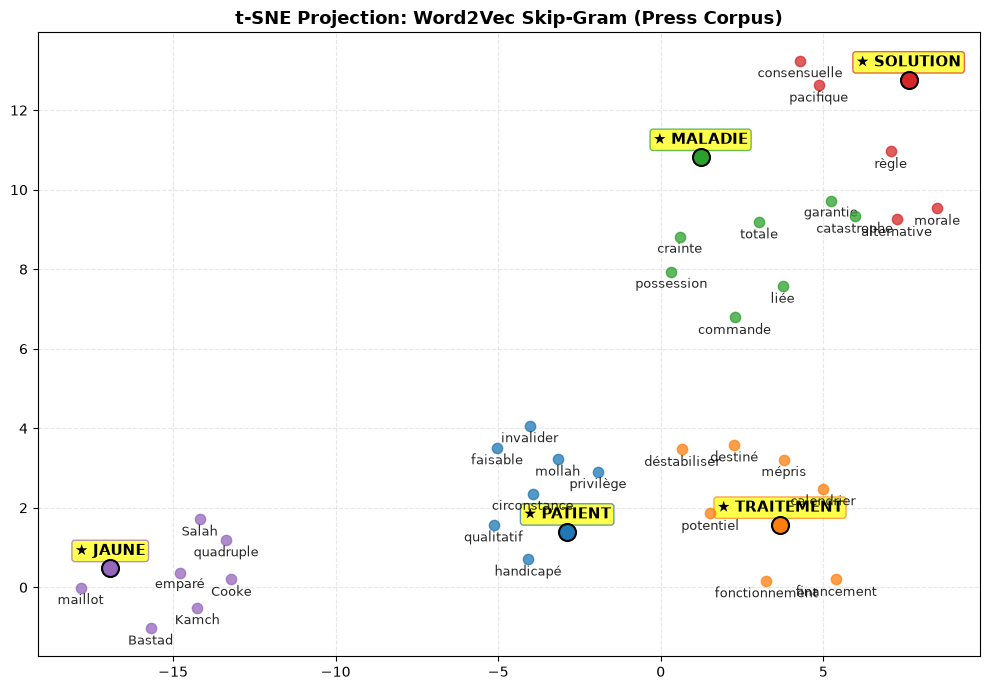

In [20]:
# Visualize Word2Vec Skip-Gram on Press
plot_tsne_comparison(models["w2v_sg_press"], candidate_words, "t-SNE Projection: Word2Vec Skip-Gram (Press Corpus)")


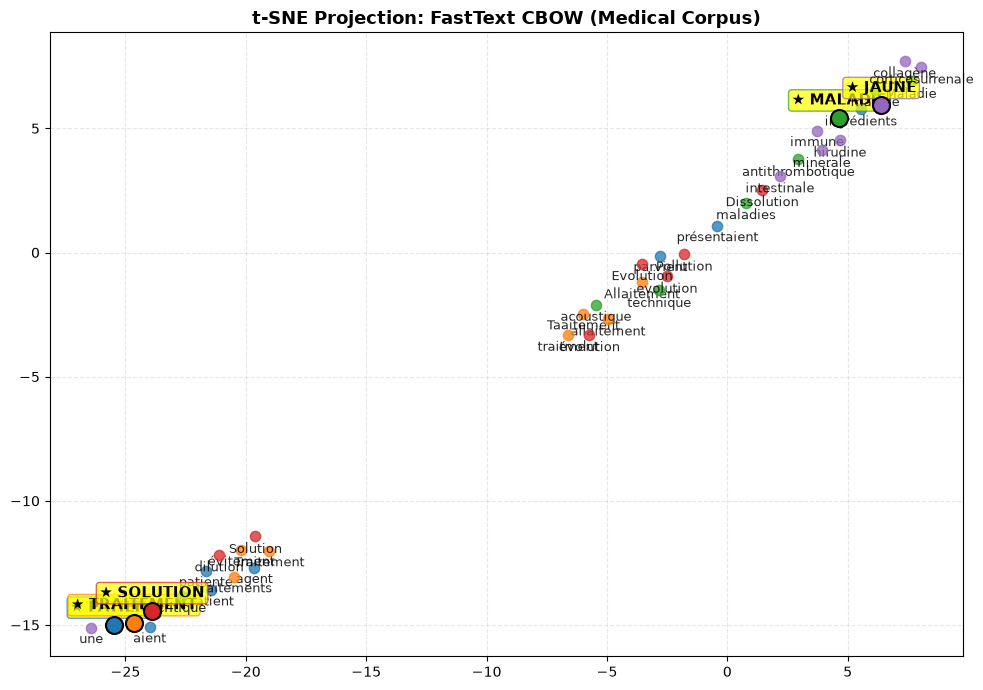

In [21]:
# Visualize FastText CBOW on Medical (Subwords and morphological clustering)
plot_tsne_comparison(models["fasttext_cbow_med"], candidate_words, "t-SNE Projection: FastText CBOW (Medical Corpus)")


The **t-SNE** visualizations provide a two-dimensional representation of the 100-dimensional embedding spaces. Each target word is displayed together with its closest neighbors, making it easier to compare the structures learned by the different models.

For the Word2Vec **Skip-gram** model trained on the Medical corpus, the target words and their neighbors form several local groups. Words such as traitement, maladie, and patient are surrounded by terms related to the medical context. This is consistent with the similarity results, where Skip-gram produced more meaningful domain-related neighbors than CBOW.

The Word2Vec **Skip-gram** model trained on the Press corpus shows a different organization. In particular, words such as solution and jaune are surrounded by neighbors that reflect their usage in press articles rather than their medical meaning. This provides a visual representation of the domain shift observed in the similarity analysis.

The **FastText** visualization for the Medical corpus also shows groups of closely located words. However, many of these groups are influenced by morphological similarity. For example, different forms of words such as traitement and maladie tend to appear close to each other because FastText represents words using character subwords.

### 6.1. Comprehensive 6-Model t-SNE Grid & Domain Shift Plots
Below we display the high-resolution comparative figures generated by `plot_tsne.py`:


--- 6-Model Comparative Grid ---


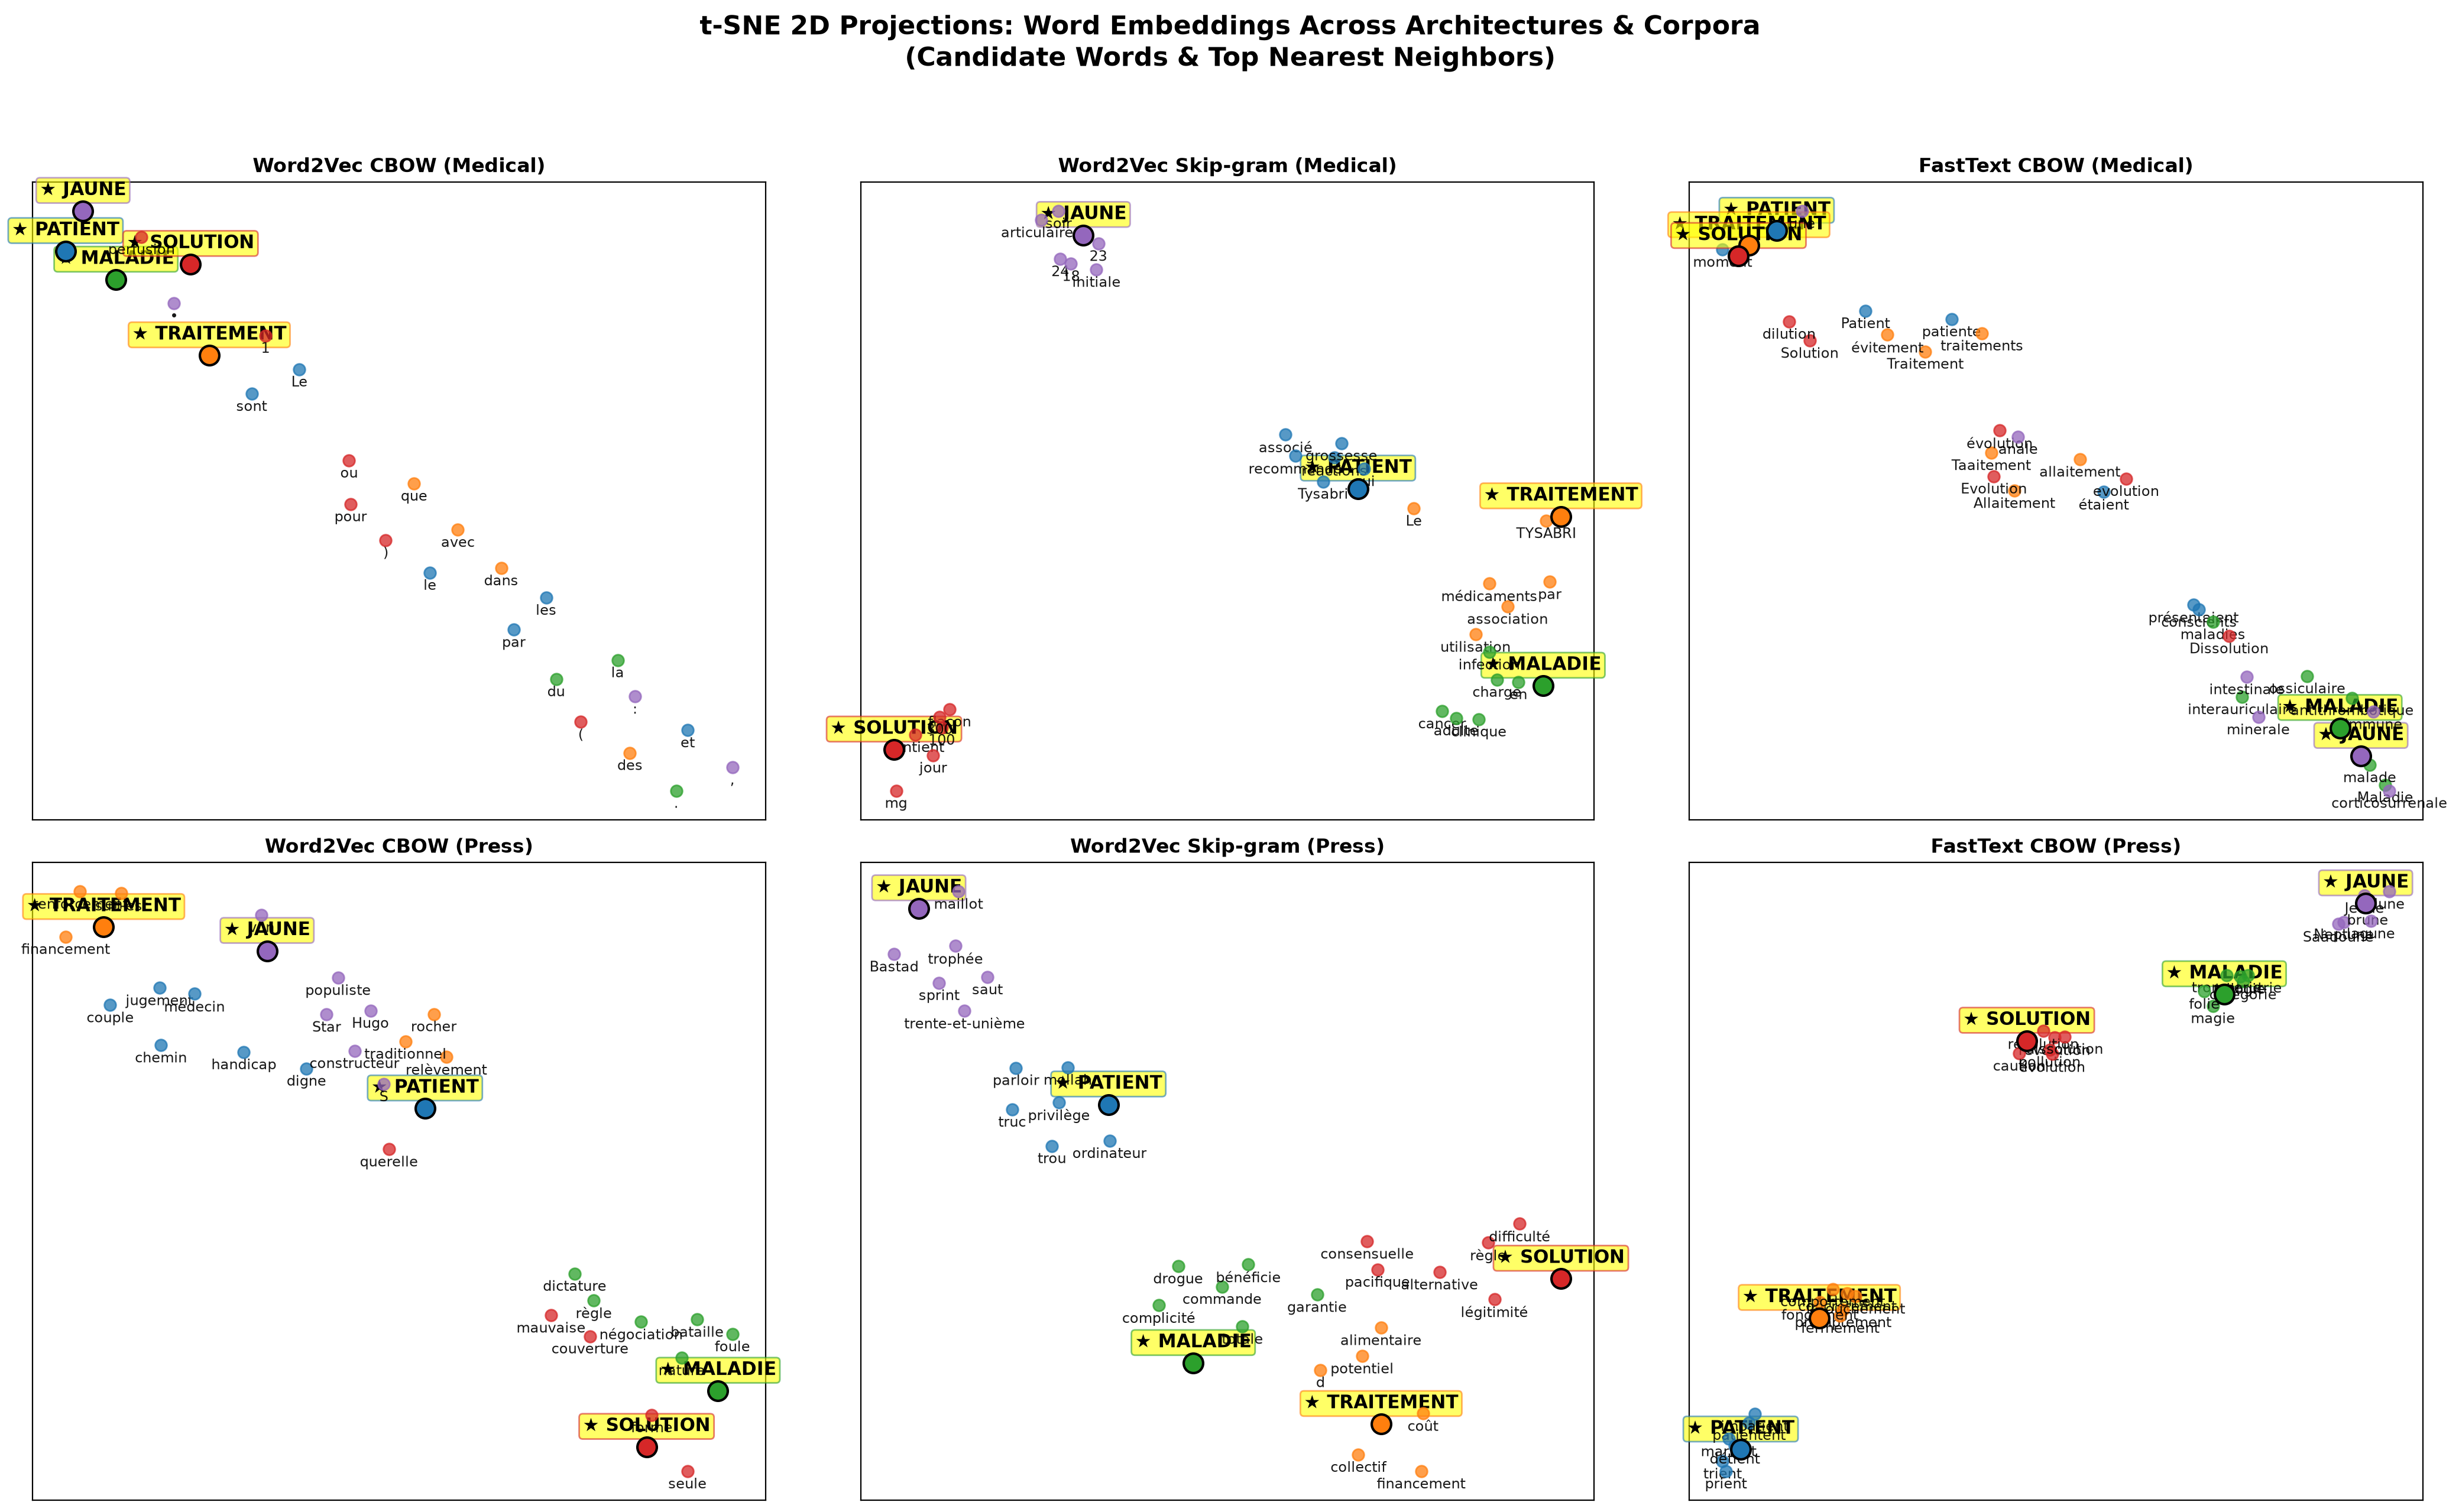

--- Domain Shift: 'solution' & 'traitement' in Medical vs. Press ---


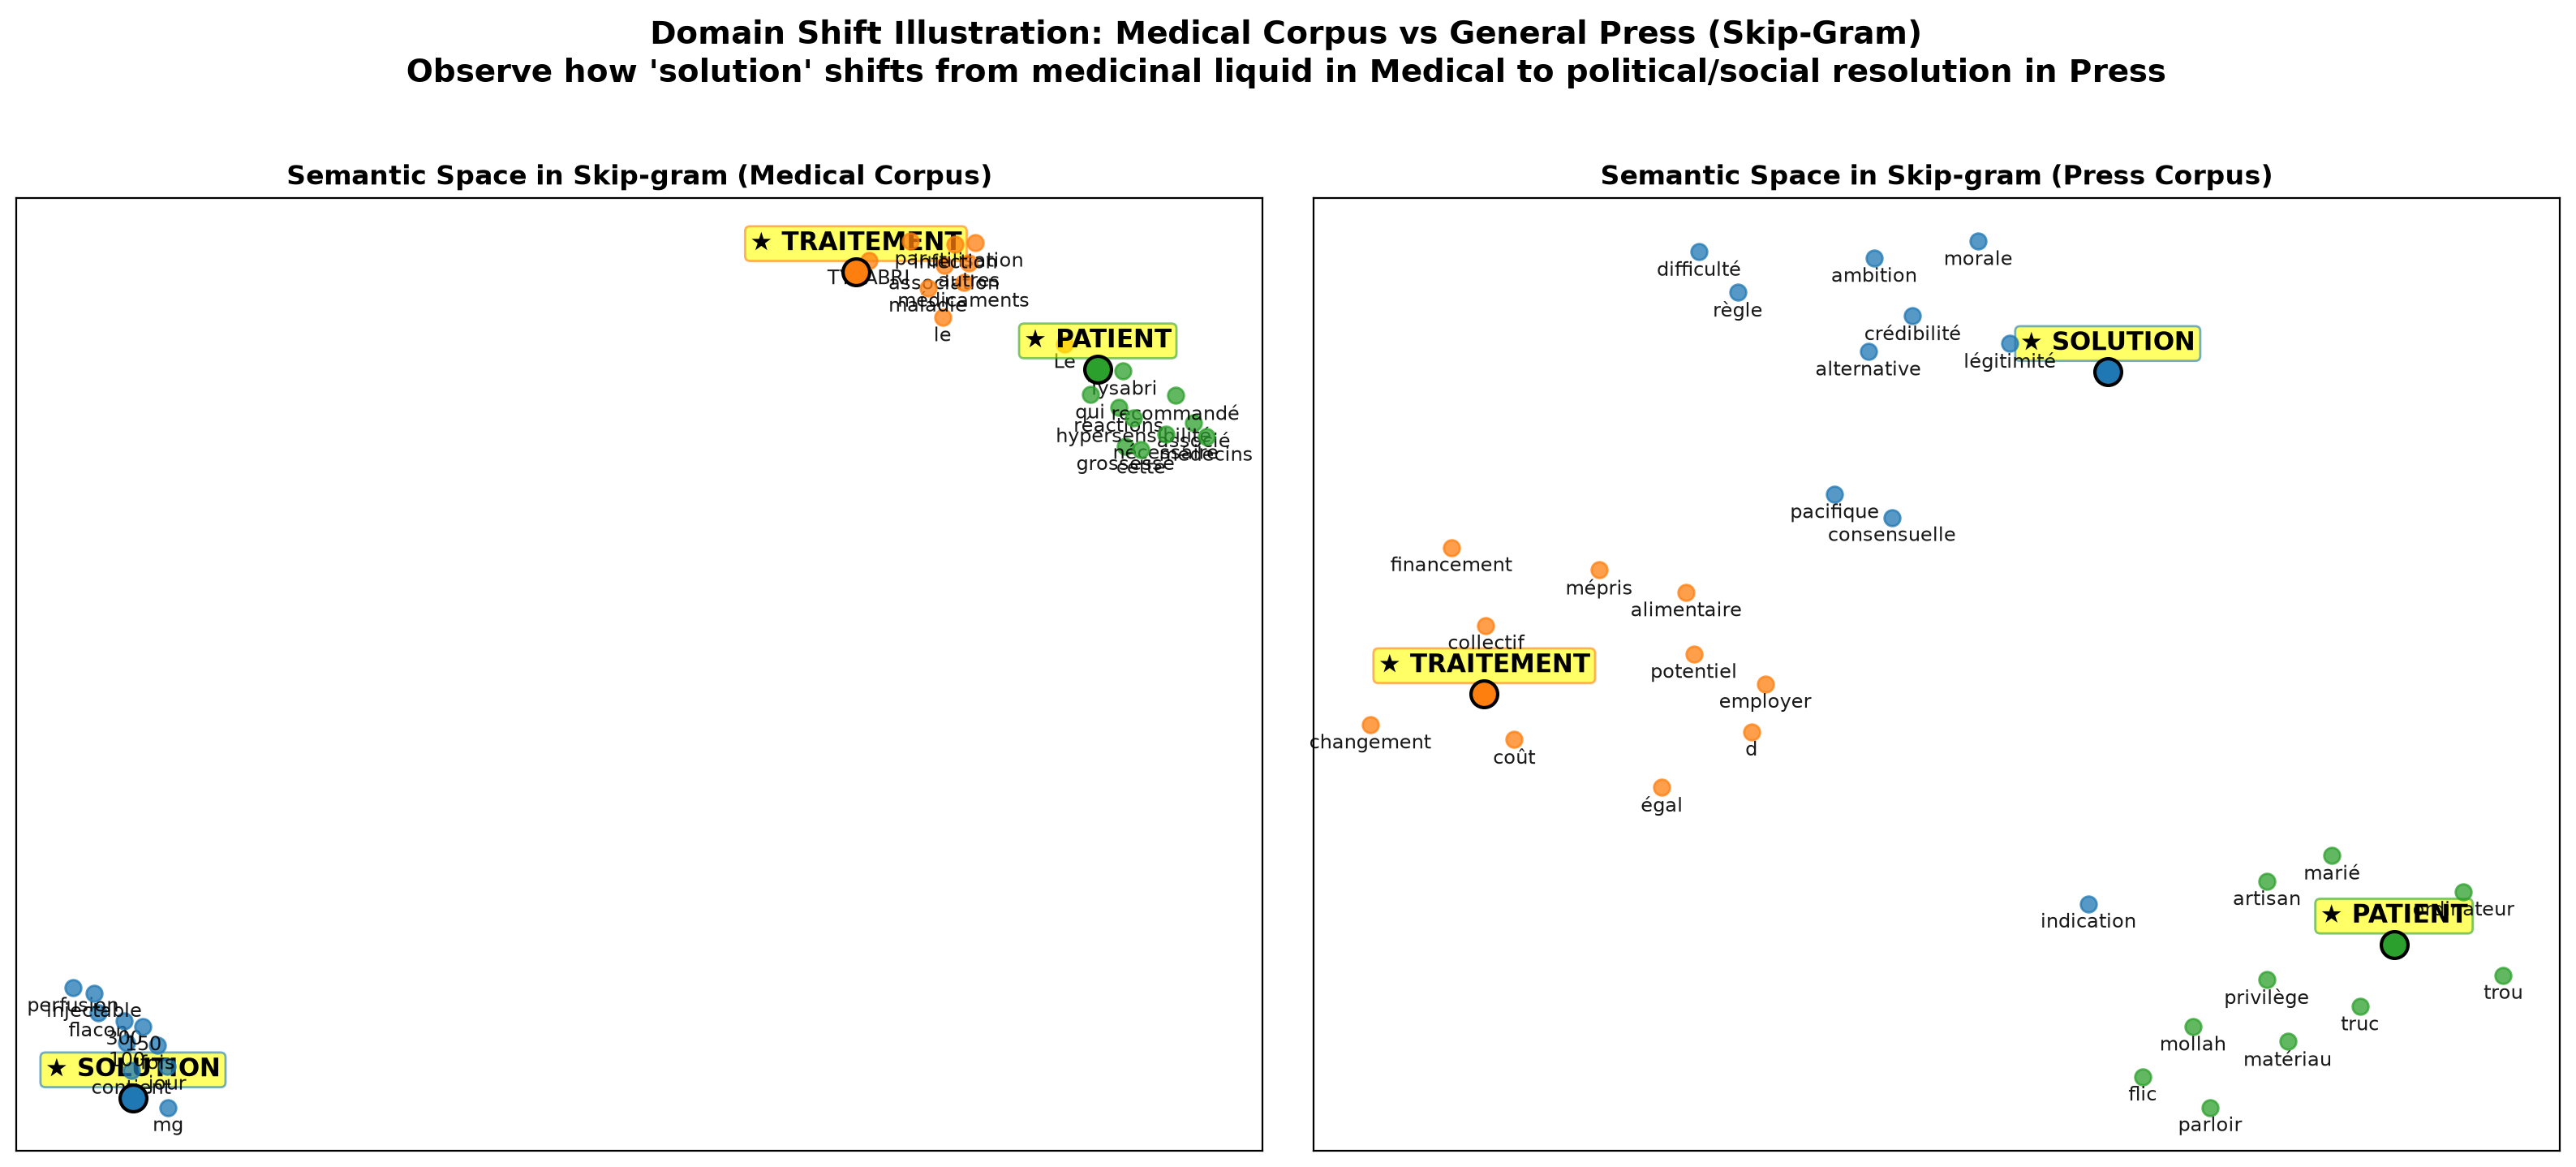

--- Architecture Comparison: Word2Vec vs FastText (Medical) ---


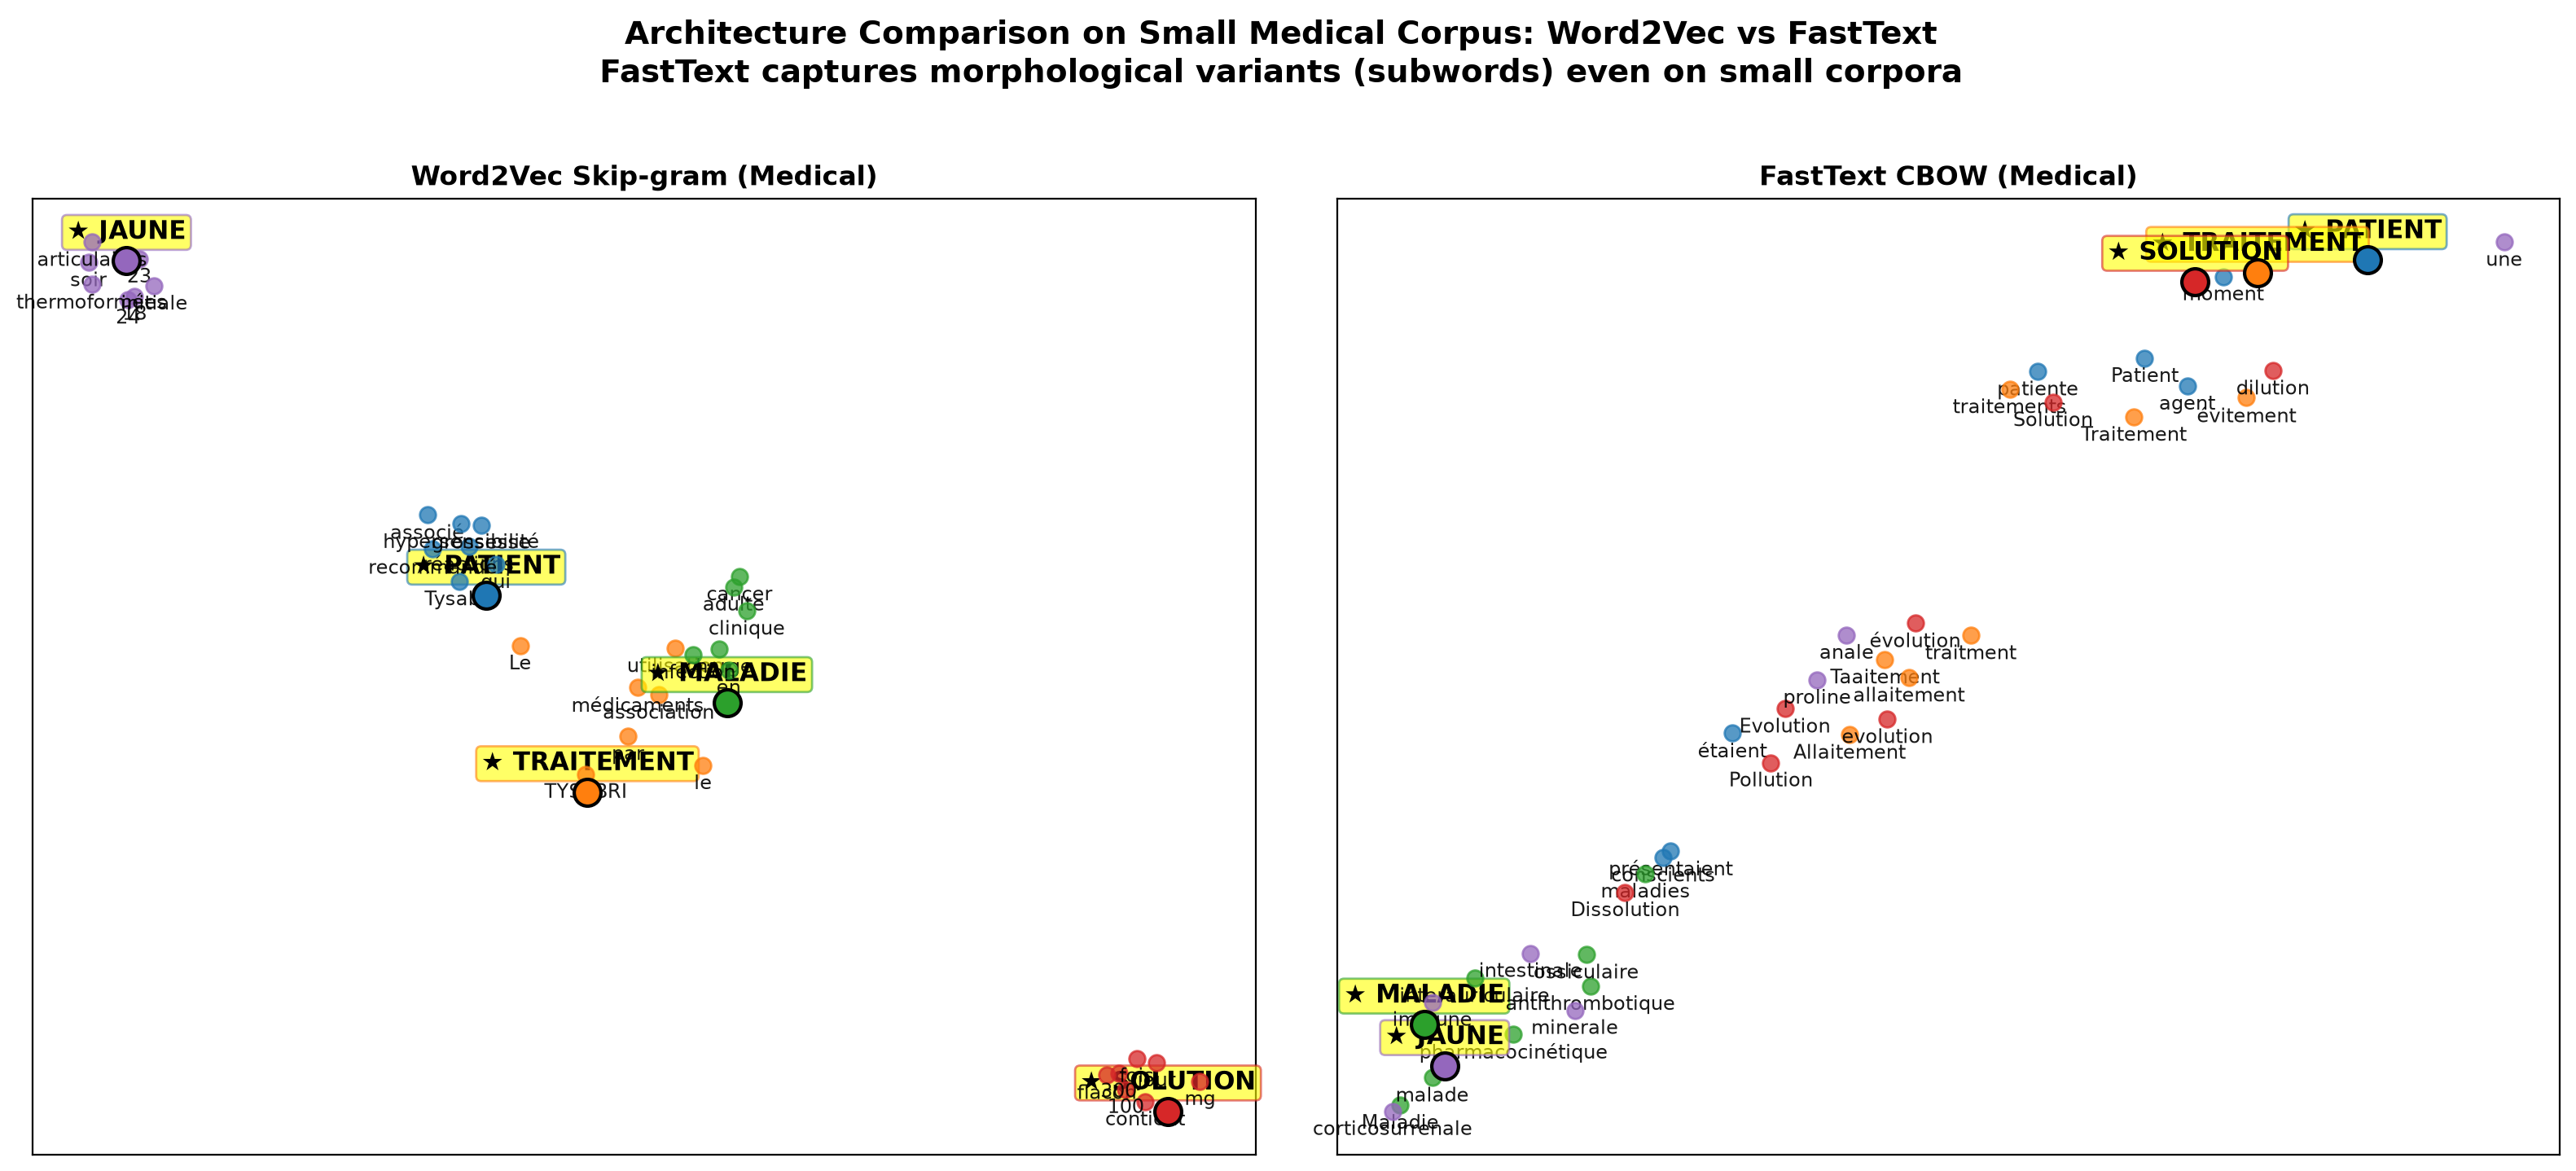

In [22]:
# Display saved overview figures
from IPython.display import Image, display

print("--- 6-Model Comparative Grid ---")
display(Image(filename=os.path.join("plots", "tsne_comparison_all_models.png")))

print("--- Domain Shift: 'solution' & 'traitement' in Medical vs. Press ---")
display(Image(filename=os.path.join("plots", "tsne_domain_shift_medical_vs_press.png")))

print("--- Architecture Comparison: Word2Vec vs FastText (Medical) ---")
display(Image(filename=os.path.join("plots", "tsne_architecture_comparison_med.png")))


The comparison of the six models makes the differences between architectures and corpora easier to observe. The **Word2Vec** models mainly organize words according to the contexts learned during training, while **FastText** also creates groups based on similarities in word structure.

The domain-shift visualization further illustrates that the same word can occupy different local neighborhoods depending on the corpus. For example, the neighbors of solution differ between the Medical and Press models, reflecting its pharmaceutical meaning in the medical corpus and its more general meaning in the press corpus.

The architecture comparison on the Medical corpus also supports the previous observations. **Skip-gram** tends to produce more interpretable semantic neighborhoods, while FastText shows stronger morphological grouping.

Overall, the t-SNE plots support the results obtained from the nearest-neighbor analysis. They show that the structure of the embedding space depends both on the model architecture and on the corpus used for training. However, because t-SNE reduces 100 dimensions to only two, the plots should mainly be used to observe local patterns rather than as an exact representation of distances in the original embedding space.

## 7. Conclusions

1. **Model Comparison**:
   - **Skip-Gram** outperforms CBOW on small specialized datasets because it avoids averaging context vectors and retains fine-grained semantic associations.
   - **FastText** provides crucial subword sensitivity, grouping morphologically related terms (for example, `-ement`, `-tion`, medical suffixes).

2. **Data Comparison**:
   - The **domain of training data dictates the semantic space**. Words like `solution` shift completely between medical formulations (perfusion/injection) and news diplomacy (compromise/accord).
   - Specialized medical tasks require in-domain embeddings: generic embeddings will induce false semantic associations.

3. **Implications for the Upcoming NER Task**:
   - In clinical Named Entity Recognition (NER), recognizing rare medical terms, drug names, and morphological disease variants is critical.
   - **FastText trained on medical data** or **Word2Vec Skip-Gram trained on medical data** are expected to deliver the highest downstream NER performance due to subword generalization and clinical precision.
